In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

np.random.seed(3141592653)

# Linear Regression

Let's begin by defining Linear Regression. At its core, linear regression allows us to predict a continuous target variable, $y$, based on a set of predictor variables, known as $X$.

To make a prediction, we multiply each input variable by a specific weight or coefficient, denoted as $\boldsymbol{\beta}$. The goal is to find the most accurate values for these coefficients. We achieve this by minimizing the Mean Squared Error (MSE), which measures the difference between our predictions and the actual values.

$$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$$

We can determine the set of weights that minimizes the loss function using the Normal Equation. Given $X$ as the matrix of input variables, the weights are calculated as follows:

$$\hat{\boldsymbol{\beta}} = (X^T X)^{-1} X^T y$$

## Exercise 1

### Simple Linear Regression

Let's go step by step. For our first exercise, we will focus on Simple Linear Regression. This is a specific case where we use only one explanatory variable to predict our target.

We are working with a dataset that tracks the delivery process of various products. It contains three main variables:

- Time Required: The total duration of the delivery.

- Number of Boxes: The quantity of items being moved.

- Distance: The total distance the shipment must travel.

We will now load this dataset and begin our initial exercises to analyze the relationships between these variables.

In [18]:
df_ex1 = pd.read_csv("logistics.txt", sep=' ')
df_ex1

,boxes,distance,time
0,10,30,24
1,15,25,27
2,10,40,29
3,20,18,31
4,25,22,25
5,18,31,33
6,12,26,26
7,14,34,28
8,16,29,31
9,22,37,39


#### a)

First, plot all the pairs of variables in the dataset and calculate the correlation between each pair. Check the values of these correlations and how they appear on the graph.

<span style="color:red">You can use the function `pd.plotting.scatter_matrix()`</span>

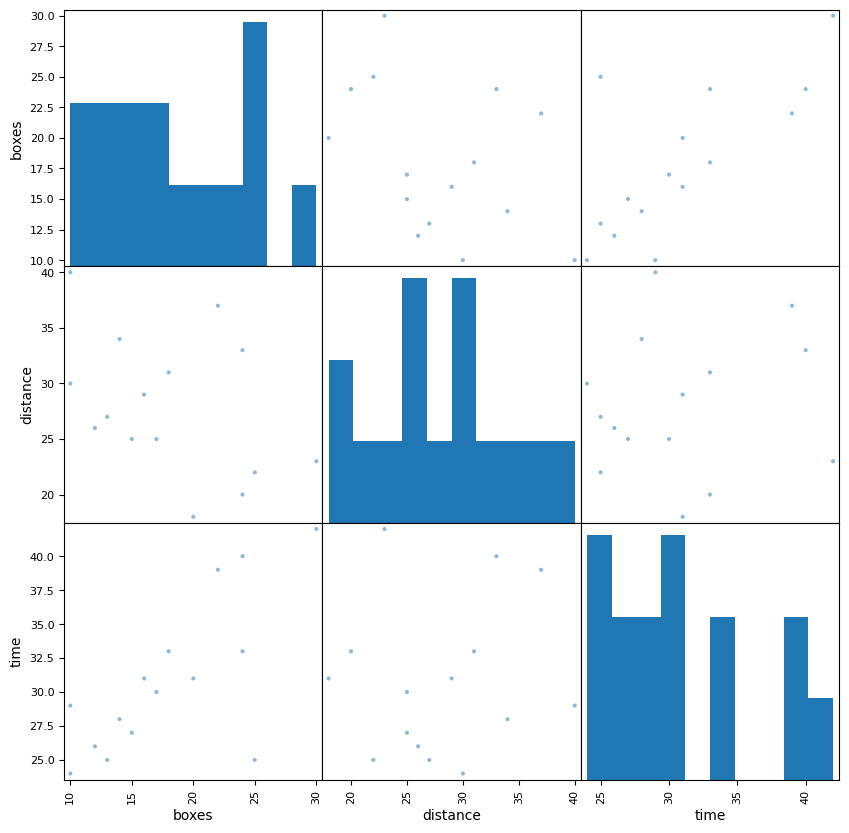

In [19]:
pd.plotting.scatter_matrix(df_ex1, figsize=(10, 10))
plt.show()

In [20]:
df_ex1.corr()

,boxes,distance,time
boxes,1.000000,-0.405298,0.724647
distance,-0.405298,1.000000,0.126903
time,0.724647,0.126903,1.000000


### b)
Create a function that receives a dataset, the name of the column of the explained variable and the explanatory one and: Calculate a linear model, do not forget to take the **intercept** into account; and shows the summary of the fitted model. The function should return the fitted model.

Then, use this function to calculate the linear model between the explanatory variable $\texttt{boxes}$ to predict $\texttt{time}$.

<span style="color:red">Use the function `model.summary()` to show the information</span>

The intercept is the first coefficient, $\beta_0$, which is not associated with any variable, but rather represents the value of the fitted line when the explanatory variable takes the value 0. It also ensures that the predicted line passes through the point $(\bar{x}, \bar{y})$.

The model we are fitting can be described as:

$$
\text{Time} = \beta_0 + \beta_1\cdot\text{Boxes}
$$

In [21]:
def linear_regression(df, dependent, independent):
    X = df[independent]
    y = df[dependent]
    X = sm.add_constant(X)
    model = sm.OLS(y, X)
    results = model.fit()
    print(results.summary()) 
    return results

simple_model = linear_regression(df_ex1, 'time', 'boxes')

                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.489
Method:                 Least Squares   F-statistic:                     14.37
Date:                Sat, 18 Apr 2026   Prob (F-statistic):            0.00224
Time:                        22:11:30   Log-Likelihood:                -41.204
No. Observations:                  15   AIC:                             86.41
Df Residuals:                      13   BIC:                             87.82
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.5452      3.414      5.432      0.0

### c)
Now that the model is fitted, write how the it is described (replace $\beta_0$ and $\beta_1$ with they actual values).

Show in a plot the values of $\texttt{boxes}$ and $\texttt{time}$ and the line corresponding to the fitted model. Make the x-axis to go from 0 to 30. Can you see the value of the fitted line when $x=30$?

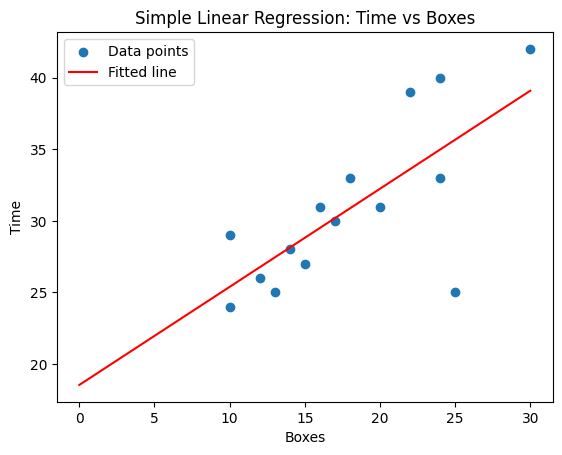

In [22]:
plt.scatter(df_ex1['boxes'], df_ex1['time'], label='Data points')
intercept = simple_model.params['const']
slope = simple_model.params['boxes']

x_vals = np.linspace(0, 30, 100)
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color='red', label='Fitted line')

plt.xlabel('Boxes')
plt.ylabel('Time')
plt.title('Simple Linear Regression: Time vs Boxes')
plt.legend()
plt.show()

<span style="color:red">
The value of the line when x=30 is 18.5452, which is the value of the intercept
</span>

$$
\text{Time} = 18.5452 + 0.6845\cdot\text{Boxes}
$$

## Exercise 2
### Multiple Linear Regression

We just saw and example using only 1 variable to model another one. We can extend this and use as many variables as we desire to better predict the target.

Now we will use a Pokemon Dataset, that collects the stats of 782 different pokemons.

In [23]:
pok = pd.read_csv("pokemon.csv", encoding='latin1').drop(columns = ["Num"])
pok

,Pokemon,HP,Attack,Defense,Sp.Atk,Sp.Def,Speed
0,Bulbasaur,45,49,49,65,65,45
1,Ivysaur,60,62,63,80,80,60
2,Mega-Venusaur,80,100,123,122,120,80
3,Venusaur,80,82,83,100,100,80
4,Charmander,39,52,43,60,50,65
...,...,...,...,...,...,...,...
778,Zygarde,108,100,121,81,95,95
779,Diancie,50,100,150,100,150,50
780,Mega-Diancie,50,160,110,160,110,110
781,Hoopa,80,110,60,150,130,70


The target variable will be Attack, and we will use the other variables to predict it.

Before we start, we should take into account the assumptions of the linear model. The three principal ones are:

- Homoscedasticity

- Linearity

- Normality of the residuals

Homoscedasticity means that the variance of the errors is constant across the entire domain of the independent variables. Linearity means that the target variable evolves linearly with respect to the explanatory ones. And finally, the normality of the residuals requires that the errors (the differences between the observed and predicted values) follow a normal distribution with a mean of zero.

### a)
Plot a graph for each pair of continuous variables. Would you say that these variables satisfy the principles of linearity and homoscedasticity?

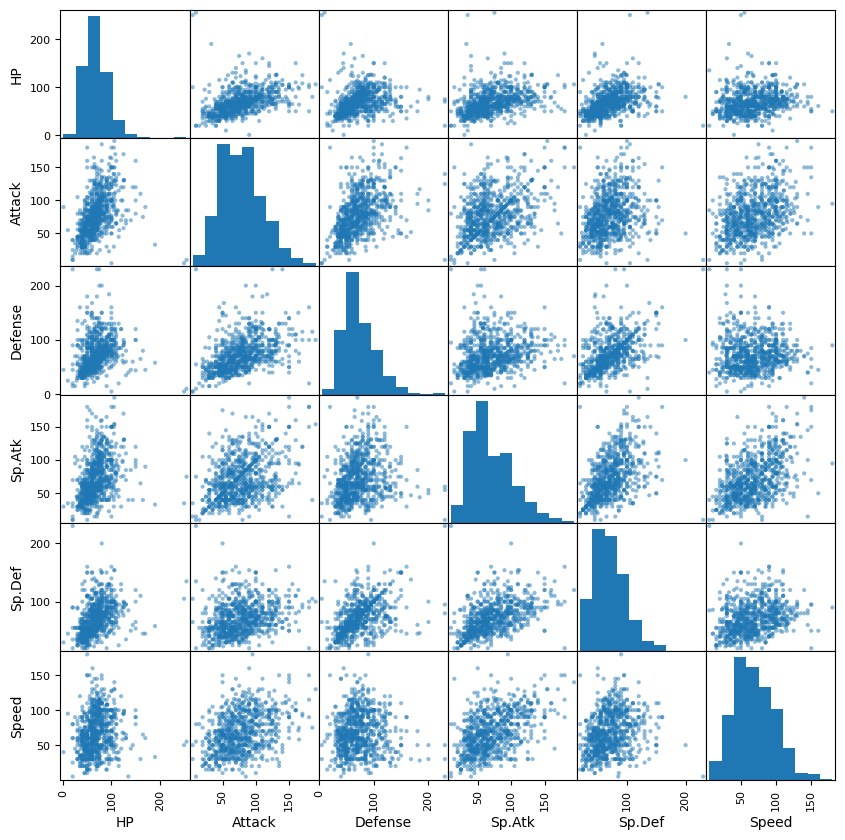

In [24]:
pd.plotting.scatter_matrix(pok, figsize=(10, 10))
plt.show()

<span style="color:red">
The conical shape of most variables casts doubt on homoscedasticity. Judging by the shape of the graphs, the variance increases with respect to the axes.

Linearity, on the other hand, appears to hold true in all the graphs. The relationship may never be exact, but at first glance we can assume that linearity is satisfied.

Ultimately, one cannot be too demanding regarding the assumptions made by the linear model, as there are very few real-world cases that will strictly satisfy all of them.
</span>

### b)
Make use of the function you created in the previous exercise, or addpt it so instead of fitting a simple linear regression with one variable, it uses a list of variables to fit a multivariate regression model. Now the function will receive as an input the dataframe, the name of the dependent variable and a list with the names of the independent ones.

Fit a model in which the dependent variable is $\texttt{Attack}$ and treat the remaining continuous variables as explanatory variables.

In [25]:
pok_model = linear_regression(pok, "Attack", ['HP', 'Defense', 'Sp.Atk', 'Sp.Def', 'Speed'])

                            OLS Regression Results                            
Dep. Variable:                 Attack   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.451
Method:                 Least Squares   F-statistic:                     129.3
Date:                Sat, 18 Apr 2026   Prob (F-statistic):           1.19e-99
Time:                        22:11:31   Log-Likelihood:                -3590.8
No. Observations:                 783   AIC:                             7194.
Df Residuals:                     777   BIC:                             7222.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.4666      3.341      1.038      0.3

### c)
Based on the summary of the model, write the equation that describe the model.

$$
\text{Attack} = 3.4666 + 0.3697\cdot\text{HP} + 0.4841 \cdot \text{Defense} + 0.1689 \cdot \text{Sp.Atk} - 0.2965 \cdot \text{Sp.Def} + 0.3378 \cdot\text{Speed}
$$

### d)
In the next sections of this exercise we will inpect the model we just created.

It is very useful in practise to use libraries to compute linear models or any kind of statistical test, however, we will follow the whole process of how these coefficients are calculated, so we show it is not just magic.

As we stated at teh beginning, the coefficients are calculated as:

$$\hat{\boldsymbol{\beta}} = (X^T X)^{-1} X^T y$$

Where $X$ is the matrix with the covariates (with a first column will all 1, that will serve for the intercept) and $y$ is the vector with the target value.

First, set $X$ and $y$, once you have them, calculate the coefficients using this formula and applying matrix-multiplication. Do you get the same coefficients as with the statsmodel function?

**Remark**: It is very important to add a first column in $X$ containing only the value $1$. Why do we do this?

In [26]:
X = pok[['HP', 'Defense', 'Sp.Atk', 'Sp.Def', 'Speed']]
X.insert(0, 'const', 1)
y = pok['Attack']

beta = np.linalg.inv(X.T @ X) @ X.T @ y
beta

0    3.466580
1    0.369671
2    0.484135
3    0.168912
4   -0.296507
5    0.337792
dtype: float64

<span style="color:red">
We got the same coefficients as the previous function

And the first column with the value $1$ is used to create the intercept, which is constant for every datapoint, so it has always the same value.
</span>

### e)

When inpecting the output of the summary function we find a column `P>|t|`. That is the p-value associated with each coefficient. The hypothesis associated with these values is:
$$
H_0:\ \beta_i=0
$$

$$
H_A:\ \beta_i\neq0
$$

Explain how we should interpret these hypothesis and the p-values associated. What does it mean to have a low p-value?

**Remark**: In the exercises of the next week we will work with feature selection, which is very related to this section.

<span style="color:red">

- $H_0$ (Null Hypothesis): Assumes the feature has no effect on the target. The coefficient is effectively zero.

- $H_A$ (Alternative Hypothesis): Assumes the feature significantly influences the target. The coefficient is not zero.

- Low p-value (in general, $p < 0.05$): You reject $H_0$. It means there is strong evidence that the variable provides a meaningful contribution to the model's predictive power.

- High p-value ($p > 0.05$): You fail to reject $H_0$. The variable is likely not statistically significant, and changes in its value don't reliably predict changes in the target. When this happens we can consider to remove the variable since it might add more noise than information in the model

**Remark**: In our case it looks that the only not relevant variable is the intercept. This happens sometimes in practise, but it use to be better to never remove the intercept. It can be better to interprete these p-values only with respect to explainatory variables. However, this is more related with model selection, that is siomething we will not cover in this subject.
</span>

### f)
One thing we haven’t done yet – and which is actually very important – is to check the model’s validity. To do this, we need to assess whether, once the linear model has been trained, it meets the requirements of linearity, homoscedasticity and normality of the residuals.

In this exercise, we are going to check all three of these aspects.

#### f.1)
There are two ways to check for linearity. The first, as we did at the start, involves plotting each explanatory variable against the response variable and assessing whether, in each case, the relationship follows a straight line. Or, as we will do now, once the model has been trained: plotting the predictions from the training data against the actual values. If this comparison appears to follow a diagonal line, that could be a good indicator that linearity has been achieved.

Why this is a good method? If the predicted values and the the real ones are in a diagonal line, it mean that, for a prediction of 100, the actual value is around 100, for a prediction of 50, teh actual value is 50, and so on in the whole domain. If we find that there is a strange shape, for instance, it is closer to a curve line, would mean that the relationship prediction- reality is not linear. Or if the shape is a vertical or horizontal line would mean that the model is actually not predicting anything valuable, predictions and reality might be independent.  

So now, the steps consist on: with the model already trained, predict the values of the training data, then, plot the real values of attack against our predictions, also, add a diagonal line at a 45-degree angle. Evaluate it, would you consider it follows a diagonal behaviour?

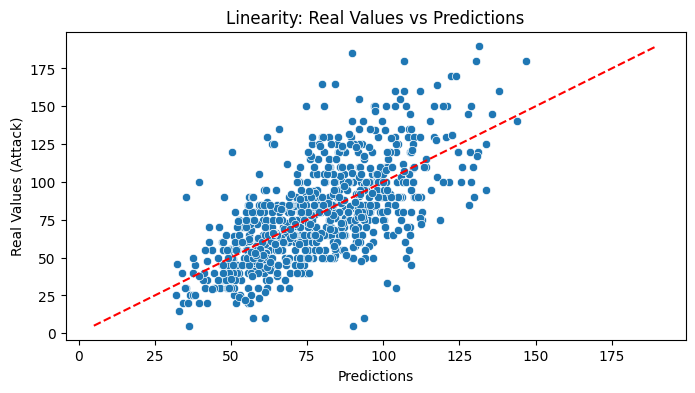

In [27]:
predictions = pok_model.predict(X)

plt.figure(figsize=(8, 4))
sns.scatterplot(x=predictions, y=y)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', ls='--')
plt.title('Linearity: Real Values vs Predictions')
plt.xlabel('Predictions')
plt.ylabel('Real Values (Attack)')
plt.show()

<span style="color:red">
The cloud of points is relatively wide, but the linearity is accomplished since a diagonal shape is evident.
</span>

#### f.2)
To check homocedasticity we want to see if the variance keeps constant in the whole domein of the variable. To do that we use the residuals of our training, we can access to it with `model.resid`.

What we can do is plot a graph with the predicted values on the x-axis and the residuals on the y-axis. What we would expect to see is a horizontal line in the shape of a rectangle. If, instead of a rectangle, we see a cone, this could indicate that the variance depends on the prediction and that the model performs better in some intervals than in others; similarly, if we see a diagonal shape, this means that the model is biased.

Plot the residuals against the predicted values. Do you see a horizontal behaviour? Is is constantly the same or it variates in different intervals?

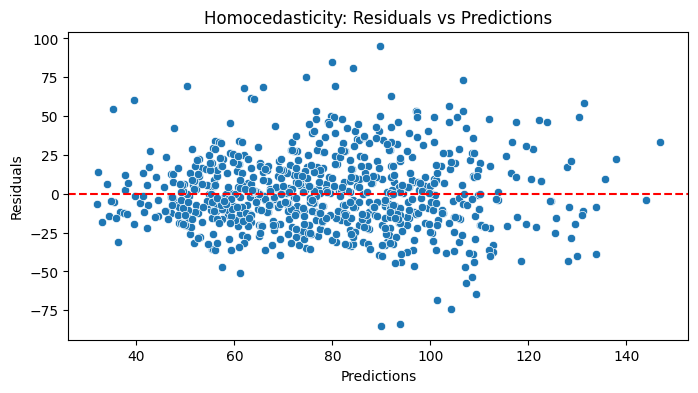

In [28]:
resi = pok_model.resid

plt.figure(figsize=(8, 4))
sns.scatterplot(x=predictions, y=resi)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Homocedasticity: Residuals vs Predictions')
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.show()

<span style="color:red">
One may argue that the shape is narrower with small values and wider as it grows, however, it can be aceptable.
</span>

### f.3)
Finally, normality of the residuals. To chech this property we will just compare the distribution of the residuals we were using before with the "expected" behaviour if they were normally distributed. To do so you can use `sm.qqplot`, which will plot the quantiles of the Gaussian distribution with ours. If the points are close to the straight line, that means the requirement is achieved.

Show the QQ-Plot of the residuals. What is your opinion, the residuals follow the quantiles or the do not?

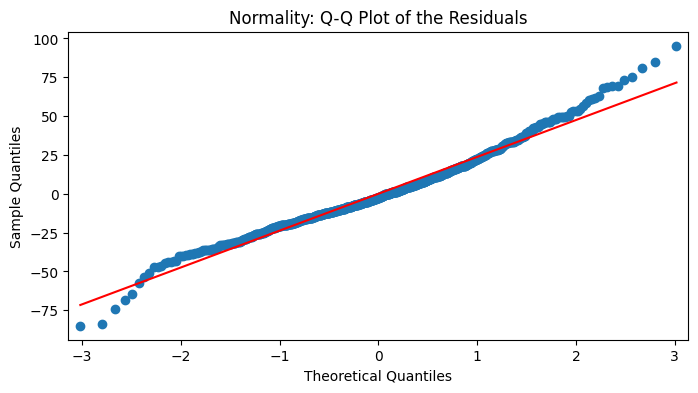

In [29]:
plt.figure(figsize=(8, 4))
sm.qqplot(resi, line='s', ax=plt.gca())
plt.title('Normality: Q-Q Plot of the Residuals')
plt.show()

<span style="color:red">
The most common behaviour observed doing these plots is that they may diverge at the begining and at the end, but in most of the domain, the middle one (the most relevant) the expectation and the observed is very close so we can assume normality in the residuals. 
</span>

## Exercise 3
### a)

Now it is time to put our model into practise. Let's predict!

[Sprigatito](https://pokemon.fandom.com/wiki/Sprigatito) is not in the dataset, we can easily access pokédex and check its stats.
With the next stats, give a prediction for the Attack of Sprigatito. What do you consider about this prediction?

- HP: 40
- Attack: ??
- Defense: 54
- Sp. Atk: 45
- Sp. Def: 45
- Speed: 65

In [30]:
sprigatito = pd.DataFrame({
    "constant": [1],
    'HP': 40,
    'Defense': 54,
    'Sp.Atk': 45,
    'Sp.Def': 45,
    'Speed': 65
})

prediction_sprigatito = pok_model.predict(sprigatito)

print("Prediction:", prediction_sprigatito.iloc[0])

Prediction: 60.61142947944446


<span style="color:red">
The actual value of the Attack of Sprigatito is 61, so it is a very good estimation
</span>

### b)
Shuckle appears in our training dataset. Find the row for Shuckle and calculate its ‘Attack’ value. Compare this with the actual value. What do you notice? What might be happening? Can we consider Shuckle to be an outlier?

In [31]:
shuckle_row = pok[pok['Pokemon'] == 'Shuckle']
shuckle_data = shuckle_row[['HP', 'Defense', 'Sp.Atk', 'Sp.Def', 'Speed']].copy()
shuckle_data.insert(0, 'const', 1)
predicted_attack = pok_model.predict(shuckle_data)
print("Shuckle stats:")
print(shuckle_row)
print("Predicted Attack for Shuckle ->", predicted_attack.iloc[0])
print("Actual Attack for Shuckle ->   ", shuckle_row['Attack'].iloc[0])

Shuckle stats:
     Pokemon  HP  Attack  Defense  Sp.Atk  Sp.Def  Speed
229  Shuckle  20      10      230      10     230      5
Predicted Attack for Shuckle -> 57.39248768290747
Actual Attack for Shuckle ->    10


<span style="color:red">
Shuckle is a rather unusual Pokémon in terms of its stats. It has incredible Defence but a terrible Attack, so you can use it as a tank to absorb a constant barrage of attacks, but when it attacks, it will barely make a dent.

And yes, it is the best difinition of an outlier.
</span>

### c)
Finally, search if any of your favourite pokemons are contained in our dataset, if they are not, find the its stats on the pokédex and get a prediction for its Attack. How do you consider it?

In [32]:
# This is a possible solution, you might have chosen a different Pokemon, but the process is the same.
# Example with Fuecoco

fuecoco = pd.DataFrame({
    "constant": [1],
    'HP': 67,
    'Defense': 59,
    'Sp.Atk': 63,
    'Sp.Def': 40,
    'Speed': 36
})
prediction_fuecoco = pok_model.predict(fuecoco)
print("Prediction:", prediction_fuecoco.iloc[0])
print("Actual value:", 45)

Prediction: 67.74020350422249
Actual value: 45
